# Homework

## Problem 1

Let $f(x) = 2\sin x - \cos{2x}$. Write a function `beauty_derivative_plot` that takes a point $x$ and plots the function $f(x)$ and its derivative $f'(x)$ in the range $x \in [-2\pi, 2\pi]$. The function should also plot the tangent line to the function at the point $x$.

Example of output for $x = -3, -2, 1.7$:

```python
beauty_derivative_plot(-3)
```
<img src="https://i.ibb.co/zTdYLC0J/tangent-line-3-0.png" width="600"/>

```python
beauty_derivative_plot(-2)
```
<img src="https://i.ibb.co/hFXNZ7wS/tangent-line-2-0.png" width="600"/>

```python
beauty_derivative_plot(1.7)
```
<img src="https://i.ibb.co/217yHstn/tangent-line-1-7.png" width="600"/>

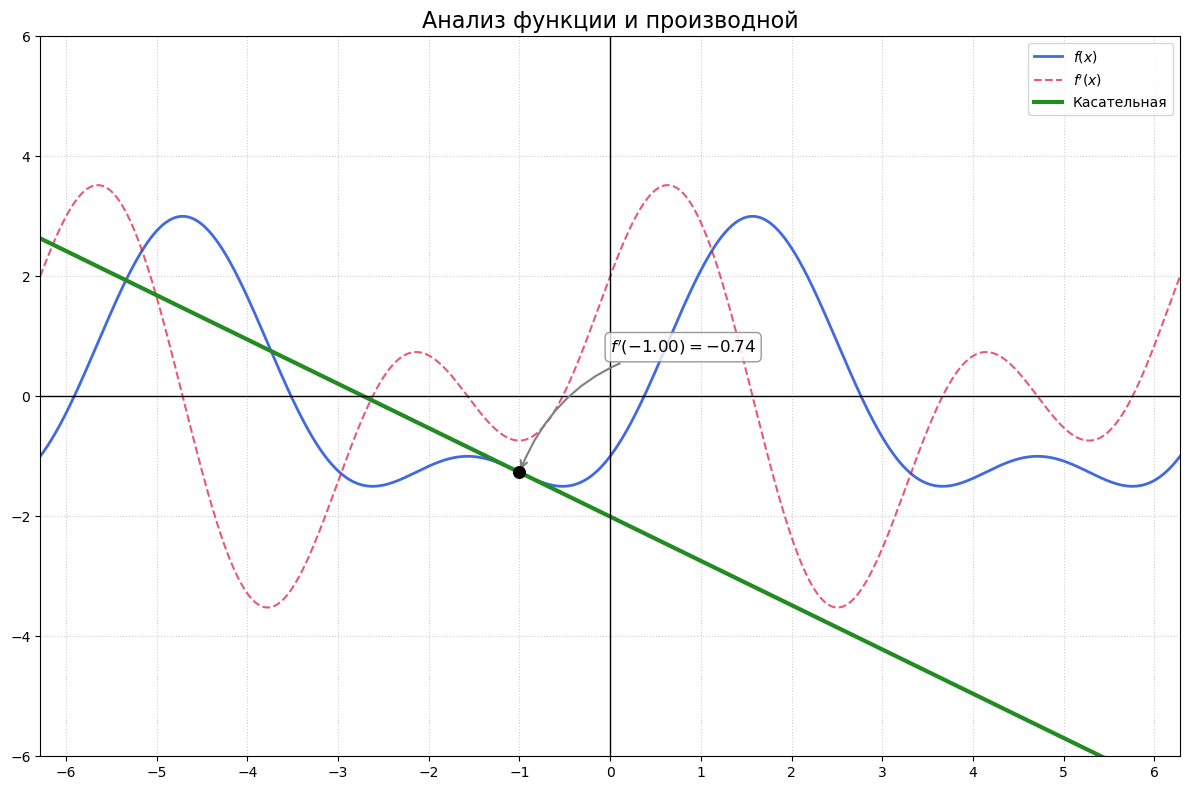

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def beauty_derivative_plot(x0):
    x = np.linspace(-2 * np.pi, 2 * np.pi, 1000)
    
    f_x = 2 * np.sin(x) - np.cos(2 * x)
    df_x = 2 * np.cos(x) + 2 * np.sin(2 * x)
    
    f_x0 = 2 * np.sin(x0) - np.cos(2 * x0)
    df_x0 = 2 * np.cos(x0) + 2 * np.sin(2 * x0)
    
    tangent_line = df_x0 * (x - x0) + f_x0
    
    plt.figure(figsize=(12, 8))
    
    plt.plot(x, f_x, label=r'$f(x)$', color='royalblue', linewidth=2)
    plt.plot(x, df_x, label=r"$f'(x)$", color='crimson', linestyle='--', linewidth=1.5, alpha=0.7)
    plt.plot(x, tangent_line, label='Касательная', color='forestgreen', linewidth=3)
    
    plt.scatter([x0], [f_x0], color='black', s=70, zorder=5)

    plt.annotate(
        f"$f'({x0:.2f}) = {df_x0:.2f}$",
        xy=(x0, f_x0), 
        xytext=(x0 + 1, f_x0 + 2),
        fontsize=12,
        fontweight='bold',
        arrowprops=dict(
            arrowstyle="->",
            connectionstyle="arc3,rad=.3",
            color='gray',
            lw=1.5
        ),
        bbox=dict(boxstyle="round,pad=0.3", edgecolor="gray", facecolor="white", alpha=0.8)
    )
    
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)
    
    x_ticks = np.arange(-6, 7, 1)
    plt.xticks(x_ticks)
    plt.grid(True, which='both', linestyle=':', alpha=0.6)
    
    plt.xlim(-2 * np.pi, 2 * np.pi)
    plt.ylim(-6, 6)
    
    plt.title('Анализ функции и производной', fontsize=16)
    plt.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

beauty_derivative_plot(-1)

## Problem 2

The data in [populations.txt](http://www.scipy-lectures.org/_downloads/populations.txt) describes the populations of hares, lynxes and carrots in northern Canada during 20 years. Get the data with
```python
np.loadtxt('http://www.scipy-lectures.org/_downloads/populations.txt')
```
and do the following exercises **without for-loops (!!!)**.

- Plot the population size of each species for each year on a single graph. Add legend and axis labels to the plot.

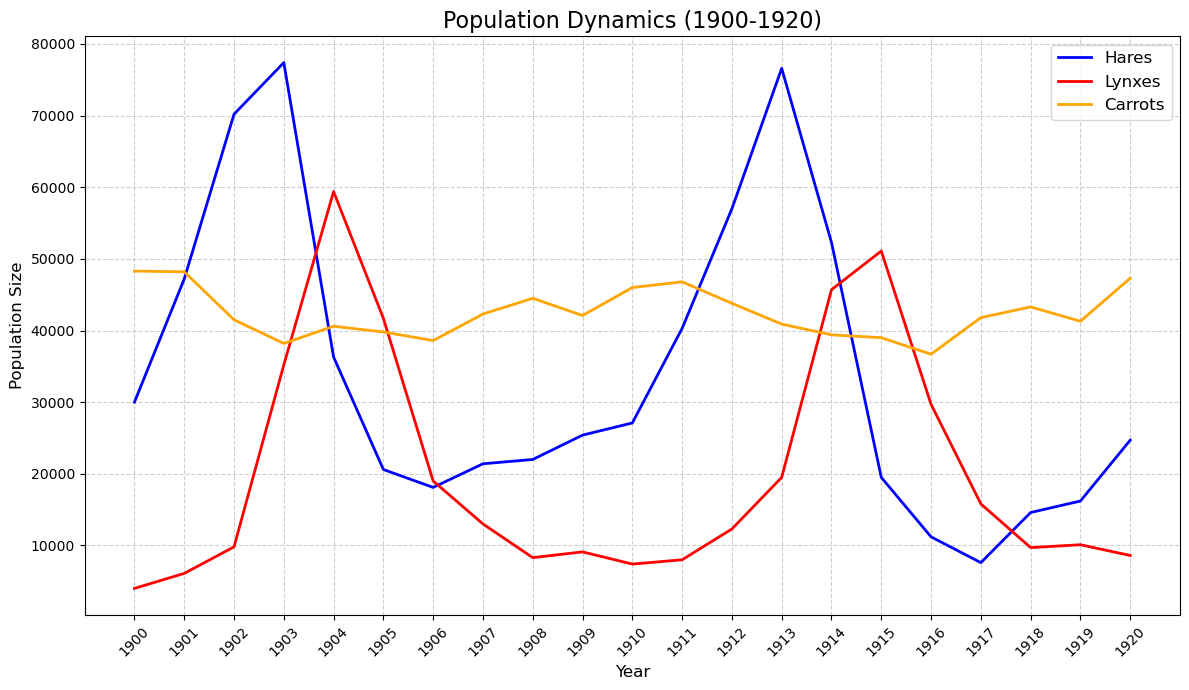

In [2]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('populations.txt', skiprows=1)

years = data[:, 0]
hares = data[:, 1]
lynxes = data[:, 2]
carrots = data[:, 3]

plt.figure(figsize=(12, 7))

plt.plot(years, hares, label='Hares', color='blue', linewidth=2)
plt.plot(years, lynxes, label='Lynxes', color='red', linewidth=2)
plt.plot(years, carrots, label='Carrots', color='orange', linewidth=2)

plt.title('Population Dynamics (1900-1920)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Population Size', fontsize=12)

plt.xticks(years, rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

- Find which year each species had the largest population. Mark these years in the plot of populations.

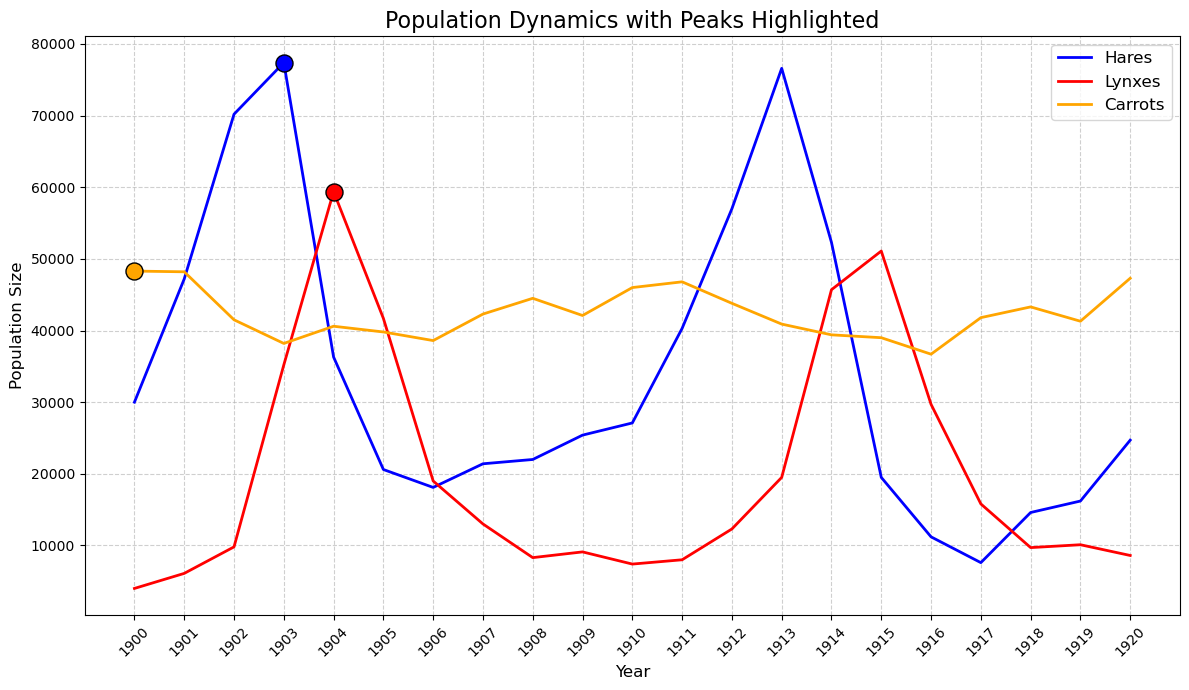

Hares peak year: 1903
Lynxes peak year: 1904
Carrots peak year: 1900


In [3]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('populations.txt', skiprows=1)

years = data[:, 0]
hares = data[:, 1]
lynxes = data[:, 2]
carrots = data[:, 3]

max_hare_idx = np.argmax(hares)
max_lynx_idx = np.argmax(lynxes)
max_carrot_idx = np.argmax(carrots)

plt.figure(figsize=(12, 7))

plt.plot(years, hares, label='Hares', color='blue', linewidth=2)
plt.plot(years, lynxes, label='Lynxes', color='red', linewidth=2)
plt.plot(years, carrots, label='Carrots', color='orange', linewidth=2)

plt.scatter(years[max_hare_idx], hares[max_hare_idx], color='blue', s=150, edgecolors='black', zorder=5)
plt.scatter(years[max_lynx_idx], lynxes[max_lynx_idx], color='red', s=150, edgecolors='black', zorder=5)
plt.scatter(years[max_carrot_idx], carrots[max_carrot_idx], color='orange', s=150, edgecolors='black', zorder=5)

plt.title('Population Dynamics with Peaks Highlighted', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Population Size', fontsize=12)

plt.xticks(years, rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

print(f"Hares peak year: {int(years[max_hare_idx])}")
print(f"Lynxes peak year: {int(years[max_lynx_idx])}")
print(f"Carrots peak year: {int(years[max_carrot_idx])}")

- Assuming total population of hares and lynxes is 100%, plot stacked bar graph showing ratio of each specis for each year in the period.

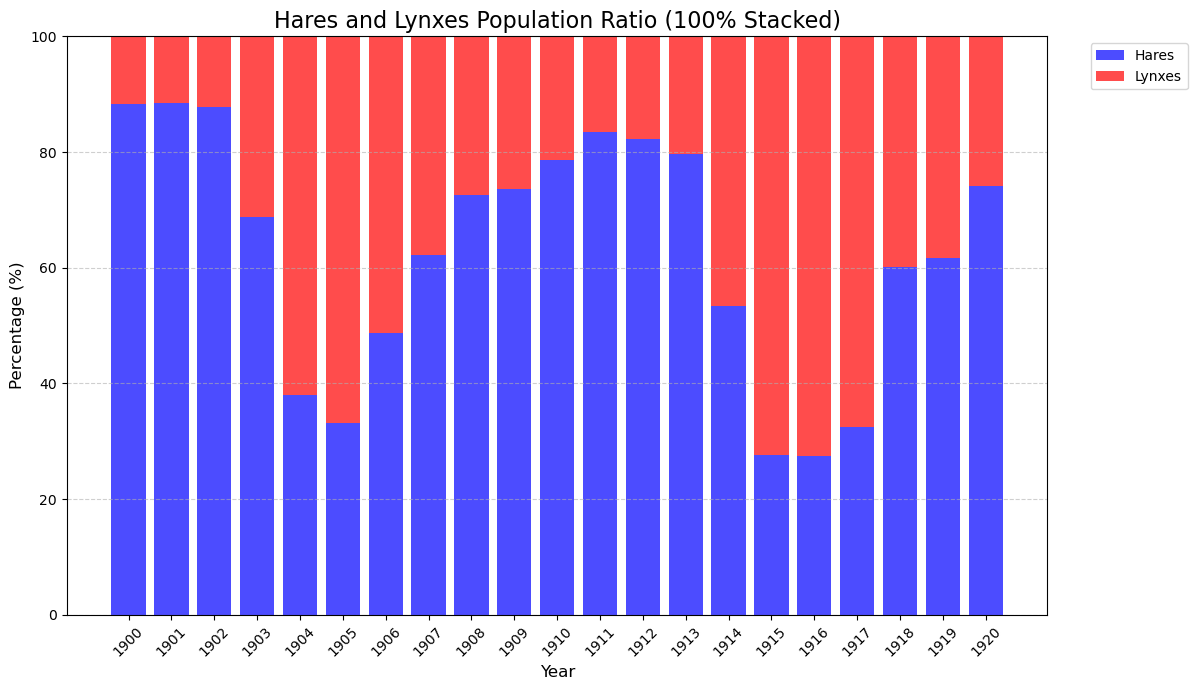

In [4]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('populations.txt', skiprows=1)

years = data[:, 0]
hares = data[:, 1]
lynxes = data[:, 2]

total = hares + lynxes

hare_percentage = (hares / total) * 100
lynx_percentage = (lynxes / total) * 100

plt.figure(figsize=(12, 7))

plt.bar(years, hare_percentage, label='Hares', color='blue', alpha=0.7)

plt.bar(years, lynx_percentage, bottom=hare_percentage, label='Lynxes', color='red', alpha=0.7)

plt.title('Hares and Lynxes Population Ratio (100% Stacked)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)

plt.xticks(years, rotation=45)
plt.ylim(0, 100)  
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))

plt.tight_layout()
plt.show()

- Find the mean and std of the populations of each species. Plot the historgam of population for each species and show mean values with vertical line. Show each histogram in a separate plot. Arrange 3 plots in a row.

Hares:   mean = 34080.95, std = 20897.91
Lynxes:  mean = 20166.67, std = 16254.59
Carrots: mean = 42400.00, std = 3322.51


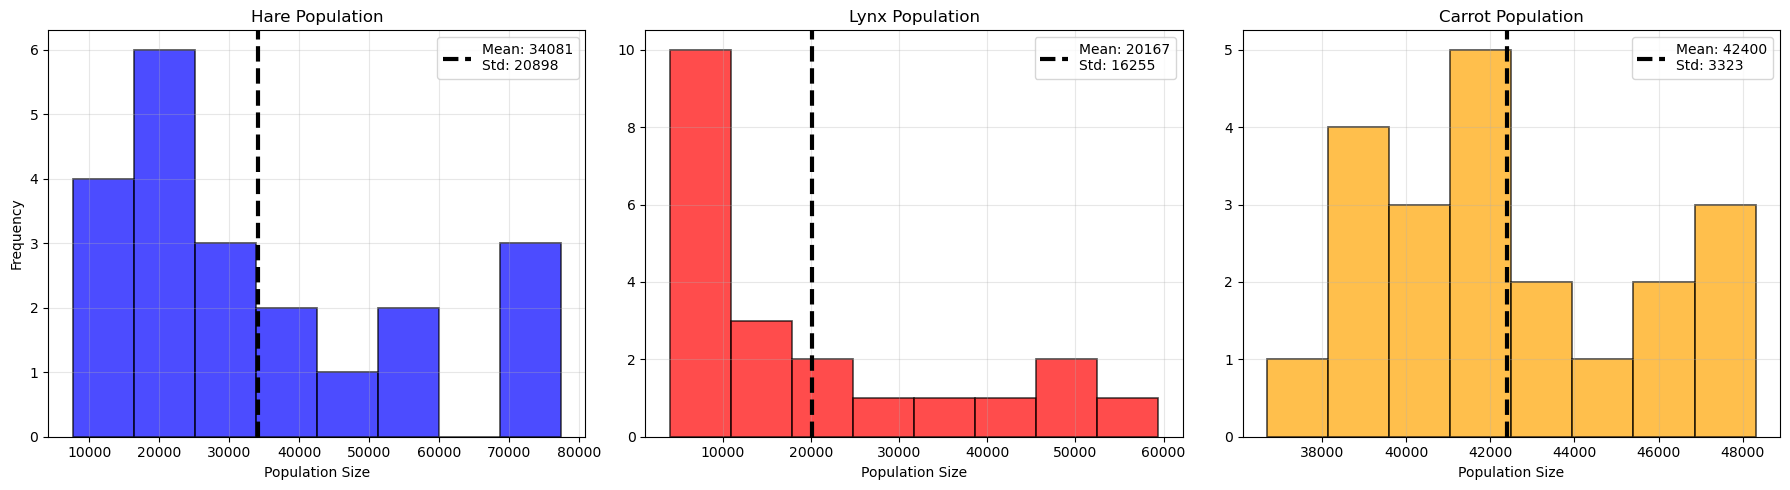

In [10]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('populations.txt', skiprows=1)

hares = data[:, 1]
lynxes = data[:, 2]
carrots = data[:, 3]

# Средние значения
mean_hare = np.mean(hares)
mean_lynx = np.mean(lynxes)
mean_carrot = np.mean(carrots)

# Стандартные отклонения
std_hare = np.std(hares)
std_lynx = np.std(lynxes)
std_carrot = np.std(carrots)

# Выводим в консоль
print(f"Hares:   mean = {mean_hare:.2f}, std = {std_hare:.2f}")
print(f"Lynxes:  mean = {mean_lynx:.2f}, std = {std_lynx:.2f}")
print(f"Carrots: mean = {mean_carrot:.2f}, std = {std_carrot:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(hares, bins=8, color='blue', alpha=0.7, edgecolor='black', linewidth=1.2)
axes[0].axvline(mean_hare, color='black', linestyle='--', linewidth=3,
                label=f'Mean: {mean_hare:.0f}\nStd: {std_hare:.0f}')
axes[0].set_title('Hare Population')
axes[0].set_xlabel('Population Size')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(lynxes, bins=8, color='red', alpha=0.7, edgecolor='black', linewidth=1.2)
axes[1].axvline(mean_lynx, color='black', linestyle='--', linewidth=3,
                label=f'Mean: {mean_lynx:.0f}\nStd: {std_lynx:.0f}')
axes[1].set_title('Lynx Population')
axes[1].set_xlabel('Population Size')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].hist(carrots, bins=8, color='orange', alpha=0.7, edgecolor='black', linewidth=1.2)
axes[2].axvline(mean_carrot, color='black', linestyle='--', linewidth=3,
                label=f'Mean: {mean_carrot:.0f}\nStd: {std_carrot:.0f}')
axes[2].set_title('Carrot Population')
axes[2].set_xlabel('Population Size')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- Find which species (hares or lynxes) has the largest population for each year. Print the result as [H, H, L, H, ...]. Plot a pie chart showing the ratio of "H" and "L" values.

['H', 'H', 'H', 'H', 'L', 'L', 'L', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'L', 'L', 'L', 'H', 'H', 'H']


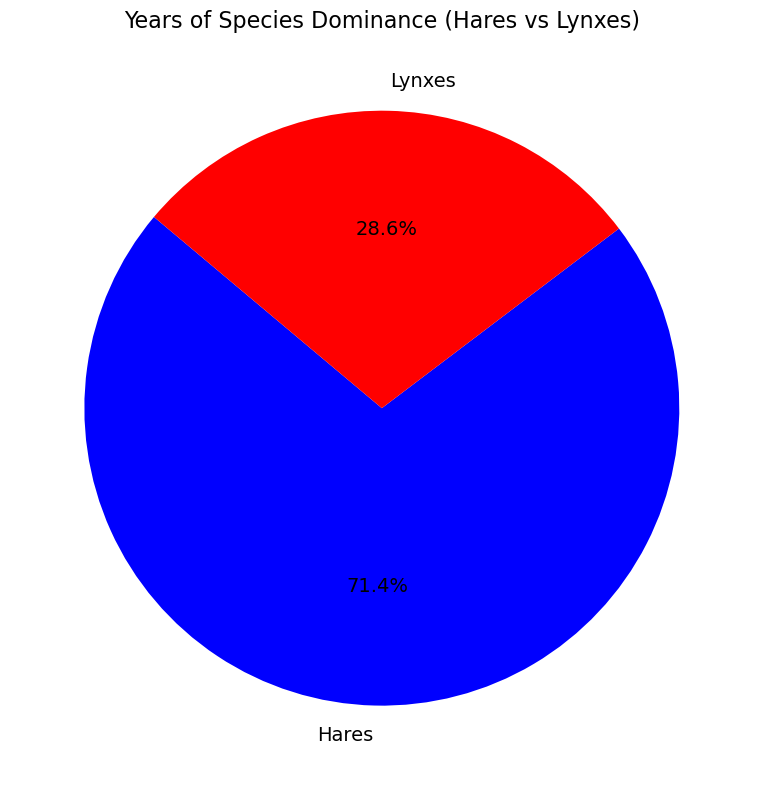

In [6]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('populations.txt', skiprows=1)

hares = data[:, 1]
lynxes = data[:, 2]

winners = np.where(hares > lynxes, 'H', 'L')

print(winners.tolist())

h_count = np.sum(winners == 'H')
l_count = np.sum(winners == 'L')

plt.figure(figsize=(8, 8))
plt.pie([h_count, l_count], 
        labels=['Hares', 'Lynxes'], 
        autopct='%1.1f%%', 
        colors=['blue', 'red'], 
        startangle=140, 
        textprops={'fontsize': 14})

plt.title('Years of Species Dominance (Hares vs Lynxes)', fontsize=16)
plt.tight_layout()
plt.show()

- Plot the change in the hare population and in the lynx population for each year. Find the correlation coefficient between the both time series.

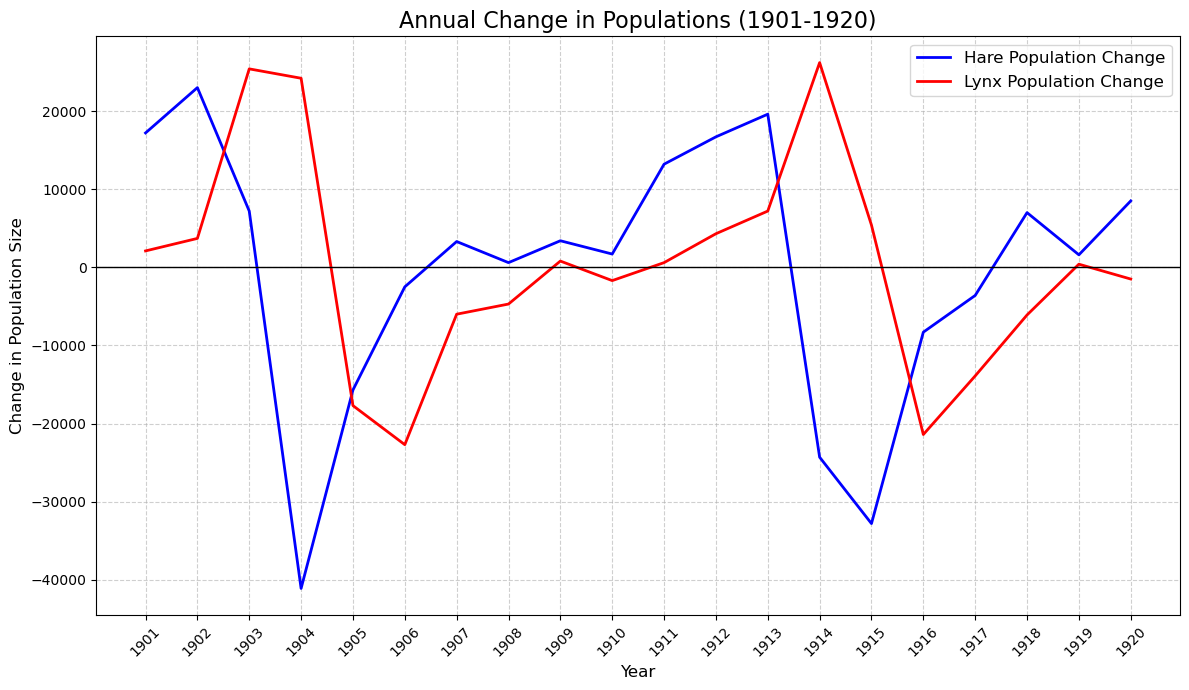

Correlation coefficient: -0.1780


In [7]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('populations.txt', skiprows=1)
years = data[:, 0]
hares = data[:, 1]
lynxes = data[:, 2]

hare_change = np.diff(hares)
lynx_change = np.diff(lynxes)
change_years = years[1:]  

correlation = np.corrcoef(hare_change, lynx_change)[0, 1]

plt.figure(figsize=(12, 7))

plt.plot(change_years, hare_change, label='Hare Population Change', color='blue', linewidth=2)
plt.plot(change_years, lynx_change, label='Lynx Population Change', color='red', linewidth=2)

plt.title('Annual Change in Populations (1901-1920)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Change in Population Size', fontsize=12)

plt.xticks(change_years, rotation=45)
plt.axhline(0, color='black', linewidth=1) 
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

print(f"Correlation coefficient: {correlation:.4f}")

- Using a scatter plot, show the population of hares vs lynxes by year (each point corresponds to a particular year, and the point coordinates correspond to the population of the two species in that year).

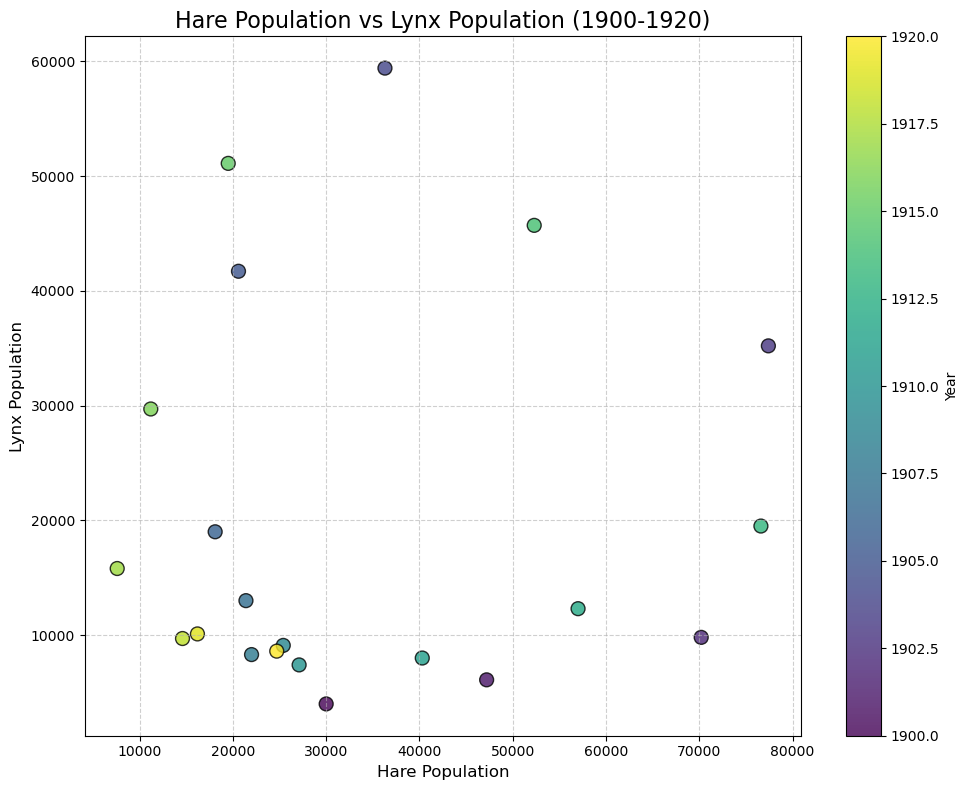

In [8]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('populations.txt', skiprows=1)
years = data[:, 0]
hares = data[:, 1]
lynxes = data[:, 2]

plt.figure(figsize=(10, 8))

scatter = plt.scatter(hares, lynxes, c=years, cmap='viridis', s=100, edgecolors='black', alpha=0.8)

plt.colorbar(scatter, label='Year')

plt.title('Hare Population vs Lynx Population (1900-1920)', fontsize=16)
plt.xlabel('Hare Population', fontsize=12)
plt.ylabel('Lynx Population', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

- Assume the population of hares in 1920 is unknown. Suggest a way to estimate this value. Compare an estimated value
with the true value and print a ratio of the error to the true value.

In [9]:
import numpy as np

data = np.loadtxt('populations.txt', skiprows=1)

years_train = data[:-1, 0]
hares_train = data[:-1, 1]
true_hare_1920 = data[-1, 1]

coeffs = np.polyfit(years_train, hares_train, 1)

estimated_hare_1920 = np.polyval(coeffs, 1920)

error_ratio = abs(estimated_hare_1920 - true_hare_1920) / true_hare_1920

print(f"Estimated Hare population in 1920: {estimated_hare_1920:.2f}")
print(f"True Hare population in 1920: {true_hare_1920:.2f}")
print(f"Error Ratio: {error_ratio:.4f}")

Estimated Hare population in 1920: 19775.79
True Hare population in 1920: 24700.00
Error Ratio: 0.1994
